# Merge Qiu and Ivan's atlasses blood subsets 

In [1]:
suppressPackageStartupMessages({
    library(data.table)
    library(Matrix)
    library(dplyr)
    library(SingleCellExperiment)
    library(scuttle)
    library(scran)
    library(batchelor)
    library(ggpubr)
})

In [2]:
blood = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Erythroid'
ivan = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/blood'
qiu = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/schendure/qiu'

#### Metadata

In [3]:
ivan_meta = fread(file.path(ivan, 'meta_blood.txt.gz'))
qiu_meta = fread(file.path(qiu, 'meta_blood.txt.gz'))

In [4]:
ivan_meta = ivan_meta[,c('cell', 'sample','stage_mixed_gastrulation_mapped', 'celltype_extended_atlas', 'embryo_version')] %>%
    setnames(c('cell', 'sample','stage', 'celltype', 'dataset'))
# For qiu's dataset, every sample is a single-cell, so put at day now instead
qiu_meta = qiu_meta[,c('cell', 'day', 'day', 'cell_type','dataset')] %>%
    setnames(c('cell', 'sample','stage', 'celltype', 'dataset'))

In [5]:
head(ivan_meta,2)
head(qiu_meta,2)

cell,sample,stage,celltype,dataset
<chr>,<int>,<chr>,<chr>,<chr>
cell_363,2,E7.5,Blood progenitors,Original
cell_382,2,E7.5,Blood progenitors,Original


cell,sample,stage,celltype,dataset
<chr>,<chr>,<chr>,<chr>,<chr>
sci3-me-001.CTACGGCATGCTAACTTGC,E10.5,E10.5,Endothelium,qiu
sci3-me-002.AGATTGGTTTTCTAATAGTA,E10.5,E10.5,Primitive erythroid cells,qiu


In [6]:
meta_big = rbind(ivan_meta, qiu_meta)
fwrite(meta_big, file.path(blood, 'meta.txt.gz'))

### SCE object merging

#### Load data

In [127]:
ivan_sce = readRDS(file.path(ivan, 'blood_sce.rds'))
qiu_sce = readRDS(file.path(qiu, 'qiu_blood_sce.rds'))

In [128]:
# Updata metadatas
colData(ivan_sce) = ivan_meta[match(colnames(ivan_sce), ivan_meta$cell)] %>% 
                        as.data.frame %>% 
                        tibble::column_to_rownames("cell") %>%
                        .[colnames(ivan_sce),] %>% DataFrame()

colData(qiu_sce) = qiu_meta[match(colnames(qiu_sce), qiu_meta$cell)] %>% 
                        as.data.frame %>% 
                        tibble::column_to_rownames("cell") %>%
                        .[colnames(qiu_sce),] %>% DataFrame()

In [129]:
orig_sce = ivan_sce[,ivan_meta[dataset=='Original', cell]]
ext_sce = ivan_sce[,ivan_meta[dataset=='Extension', cell]]

In [130]:
ncol(orig_sce)
ncol(ext_sce)

[1] 13796

[1] 50188

In [131]:
all_genes = intersect(intersect(rownames(orig_sce),rownames(ext_sce)),rownames(qiu_sce))
length(all_genes)

[1] 23584

#### Subset genes

In [132]:
# Subset genes 
all_genes = intersect(intersect(rownames(orig_sce),rownames(ext_sce)),rownames(qiu_sce))

orig_sce = orig_sce[all_genes,]
ext_sce = ext_sce[all_genes,]
qiu_sce = qiu_sce[all_genes,]

## Calculate detection rate per gene
# Number of cells expressing each gene
orig_sce_cpg = rowSums(counts(orig_sce)>0)
ext_sce_cpg = rowSums(counts(ext_sce)>0)
qiu_sce_cpg = rowSums(counts(qiu_sce)>0) 

# cellular detection rate
cpg = orig_sce_cpg + ext_sce_cpg + qiu_sce_cpg
cdr = cpg/sum(ncol(orig_sce), ncol(ext_sce), ncol(qiu_sce))

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


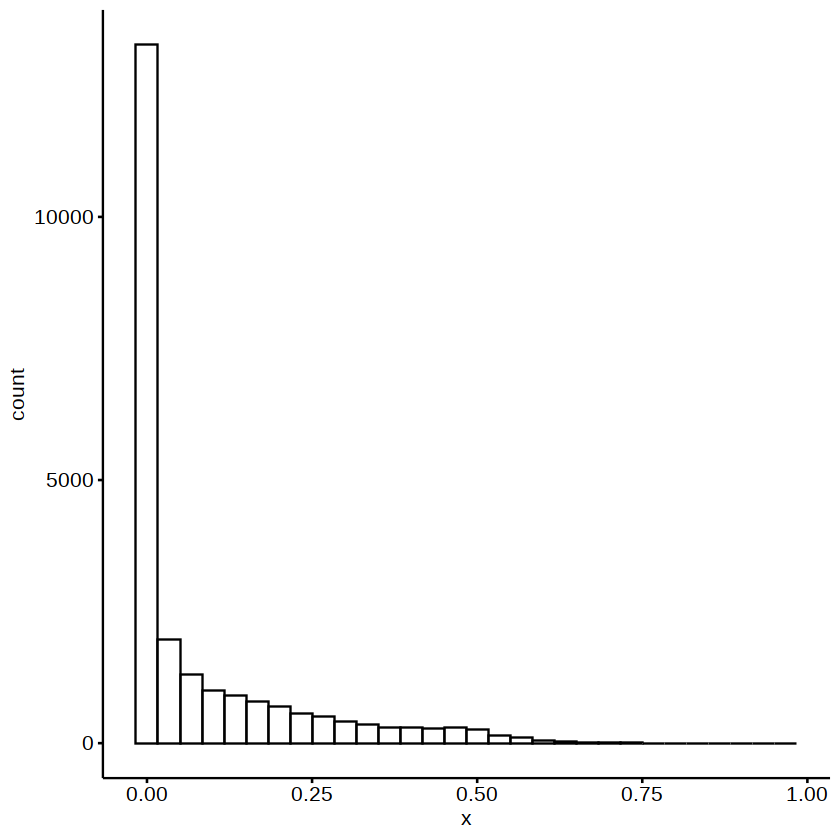

In [133]:
gghistogram(cdr)

In [134]:
# keeping genes present in 0.5% of total cells already reduces gene number to 11k
summary(cdr > 0.005)
genes_keep = names(cdr[cdr > 0.005])

orig_sce = orig_sce[genes_keep,]
ext_sce = ext_sce[genes_keep,]
qiu_sce = qiu_sce[genes_keep,]

   Mode   FALSE    TRUE 
logical   11381   12203 

#### Log normalisation per batch

In [135]:
# Normalisation, taking sample batches in to account for each dataset

assay = "cosineNorm"
# Multi batch normalisation on samples
orig_sce = multiBatchNorm(orig_sce, batch=as.factor(orig_sce$sample))
ext_sce = multiBatchNorm(ext_sce, batch=as.factor(ext_sce$sample))
qiu_sce = multiBatchNorm(qiu_sce, batch=as.factor(qiu_sce$sample))

# Cosine normalisation
assay(orig_sce, assay) = cosineNorm(assay(orig_sce, "logcounts"))
assay(ext_sce, assay) = cosineNorm(assay(ext_sce, "logcounts"))
assay(qiu_sce, assay) = cosineNorm(assay(qiu_sce, "logcounts"))


In [152]:
# Remove differences in int_colData so that we can merge
orig_sce@int_colData@listData$size_factor = NULL
ext_sce@int_colData@listData$size_factor = NULL

# Concatenate
sce = cbind(orig_sce, ext_sce, qiu_sce)

In [ ]:
    sce_all <- SingleCellExperiment(
      list(cosineNorm=cbind(assay(sce_atlas,assay), assay(sce_query,assay)))
    )

In [ ]:
# Inspect sce's
orig_sce
ext_sce
qiu_sce

class: SingleCellExperiment 
dim: 12203 13796 
metadata(0):
assays(3): counts logcounts cosineNorm
rownames(12203): ENSMUSG00000051951 ENSMUSG00000025900 ...
  ENSMUSG00000064368 ENSMUSG00000064370
rowData names(0):
colnames(13796): cell_363 cell_382 ... cell_139327 cell_139330
colData names(5): sample stage celltype dataset sizeFactor
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

class: SingleCellExperiment 
dim: 12203 50188 
metadata(0):
assays(3): counts logcounts cosineNorm
rownames(12203): ENSMUSG00000051951 ENSMUSG00000025900 ...
  ENSMUSG00000064368 ENSMUSG00000064370
rowData names(0):
colnames(50188): ext_cell_117 ext_cell_145 ... ext_cell_351871
  ext_cell_351872
colData names(5): sample stage celltype dataset sizeFactor
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

class: SingleCellExperiment 
dim: 12203 73690 
metadata(0):
assays(3): counts logcounts cosineNorm
rownames(12203): ENSMUSG00000051951 ENSMUSG00000025900 ...
  ENSMUSG00000064368 ENSMUSG00000064370
rowData names(0):
colnames(73690): sci3-me-001.CTACGGCATGCTAACTTGC
  sci3-me-002.AGATTGGTTTTCTAATAGTA ... sci3-me-758.AGTTGCGCTAATTAAGACT
  sci3-me-760.TTCGCGGATAATTAAGACT
colData names(5): sample stage celltype dataset sizeFactor
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [149]:
# might need to remove logcounts from qiu and also everything else that's different

In [153]:
sce

class: SingleCellExperiment 
dim: 12203 137674 
metadata(0):
assays(3): counts logcounts cosineNorm
rownames(12203): ENSMUSG00000051951 ENSMUSG00000025900 ...
  ENSMUSG00000064368 ENSMUSG00000064370
rowData names(0):
colnames(137674): cell_363 cell_382 ... sci3-me-758.AGTTGCGCTAATTAAGACT
  sci3-me-760.TTCGCGGATAATTAAGACT
colData names(5): sample stage celltype dataset sizeFactor
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [154]:
saveRDS(sce, file.path(blood, 'sce.rds'))